### Importy

In [33]:
import numpy as np
import math
from scipy.stats import linregress, wasserstein_distance
import matplotlib.pyplot as plt
from tqdm import tqdm

Kod z poprzednich laboratoriów:

In [16]:
def get_random_a_stable_vec(alpha, beta, gamma, delta, size):
    theta = np.random.uniform(size=size) * math.pi - math.pi/2
    W = np.random.exponential(size=size)

    if alpha == 1:
        Z = 2/math.pi * ( (math.pi/2 + beta*theta)*np.tan(theta) - beta*np.log((math.pi/2 * W*np.cos(theta)) / (math.pi/2 + beta*theta)) )
        return gamma*Z + (delta + beta * 2/math.pi * gamma * np.log(gamma))
    else:
        theta_0 = np.arctan(beta*np.tan(math.pi*alpha/2))/alpha
        Z = np.sin(alpha*(theta_0 + theta)) / ((np.cos(alpha*theta_0)*np.cos(theta))**(1/alpha)) * ( np.cos(alpha*theta_0 + (alpha - 1)*theta) / W )**((1 - alpha)/alpha)
        return gamma*Z + delta
    
def estimate_alpha_ecdf(t, tail_fraction=0.05):
    if len(t[t > 0]) < 10:
        t = np.array([-v for v in t])
        
    t = np.sort(t)
    t_pos = t[t > 0]
    if len(t_pos) < 2: return np.nan
    n_tail = min(len(t_pos), int(len(t) * tail_fraction))
    if n_tail < 2: return np.nan
    
    top_t = t_pos[-n_tail:]
    ecdf_weights = np.arange(n_tail, 0, -1) / len(t)
    lnt = np.log(top_t)
    lnfdce = np.log(ecdf_weights)
    slope, _, _, _, _ = linregress(lnt, lnfdce)
    return np.clip(-slope, 0.0, 2.0)

Stałe:

In [25]:
alpha_test = 1.5
n_samples_plot = 5000

### Zadanie 1:
(10%) Napisz generator wielowymiarowego rozkładu stabilnego dla dowolnej zadanej
dyskretnej miary spektralnej oraz parametru α. Rozważ tylko przypadek dwuwymiarowy.
Przedstaw wygenerowaną próbkę na wykresie punktowym (scatterplot). Zasymuluj
następujące przypadki:\
(a) symetryczny wektor stabilny,\
(b) wektor stabilny o niezależnych składowych,\
(c) wektor stabilny, który nie jest symetryczny i nie ma niezależnych składowych.\
Rozważ dowolne α < 2.

Korzystamy ze wzoru (zakładając, że $\alpha \neq 1$):
$$\mathbf{X} \stackrel{d}{=} \sum_{j=1}^{m} \gamma_j^{1/\alpha} Z_j \mathbf{s}_j,$$
gdzie $Z_j \sim S_\alpha(1, 1, 0)$ to niezależne, całkowicie asymetryczne jednowymiarowe zmienne stabilne.

In [45]:
def generate_discrete_stable_2d_user(alpha, angles, weights, n_samples):
    angles = np.array(angles)
    weights = np.array(weights)
    X = np.zeros((n_samples, 2))
    s = np.array([np.cos(angles), np.sin(angles)]).T
    scaled_weights = weights**(1/alpha)
    
    for j in range(len(angles)):
        Z_j = get_random_a_stable_vec(alpha, beta=1.0, gamma=1.0, delta=0.0, size=n_samples)
        X[:, 0] += scaled_weights[j] * Z_j * s[j, 0]
        X[:, 1] += scaled_weights[j] * Z_j * s[j, 1]
    return X

### Zadanie 2: 
(10%) Napisz generator wektora losowego sub-gaussowskiego. Przedstaw wygenerowaną
próbkę na wykresie punktowym (scatterplot).

$$\mathbf{X} = A^{1/2} \mathbf{G},$$
gdzie $\mathbf{G} \sim \mathcal{N}(0, \Sigma)$ to dwuwymiarowy wektor z rozkładu normalnego, a $A \sim S_{\alpha/2}(1, 1, 0)$ to dodatnia zmienna stabilna (tzw. subordynator), niezależna od $\mathbf{G}$.

In [ ]:
def generate_subgaussian_2d_user(alpha, cov_matrix, n_samples):
    A = get_random_a_stable_vec(alpha / 2, beta=1.0, gamma=1.0, delta=0.0, size=n_samples)
    A = np.maximum(A, 0) # "Just in case"
    
    G = np.random.multivariate_normal([0, 0], cov_matrix, n_samples)
    X = np.sqrt(A)[:, np.newaxis] * G
    return X

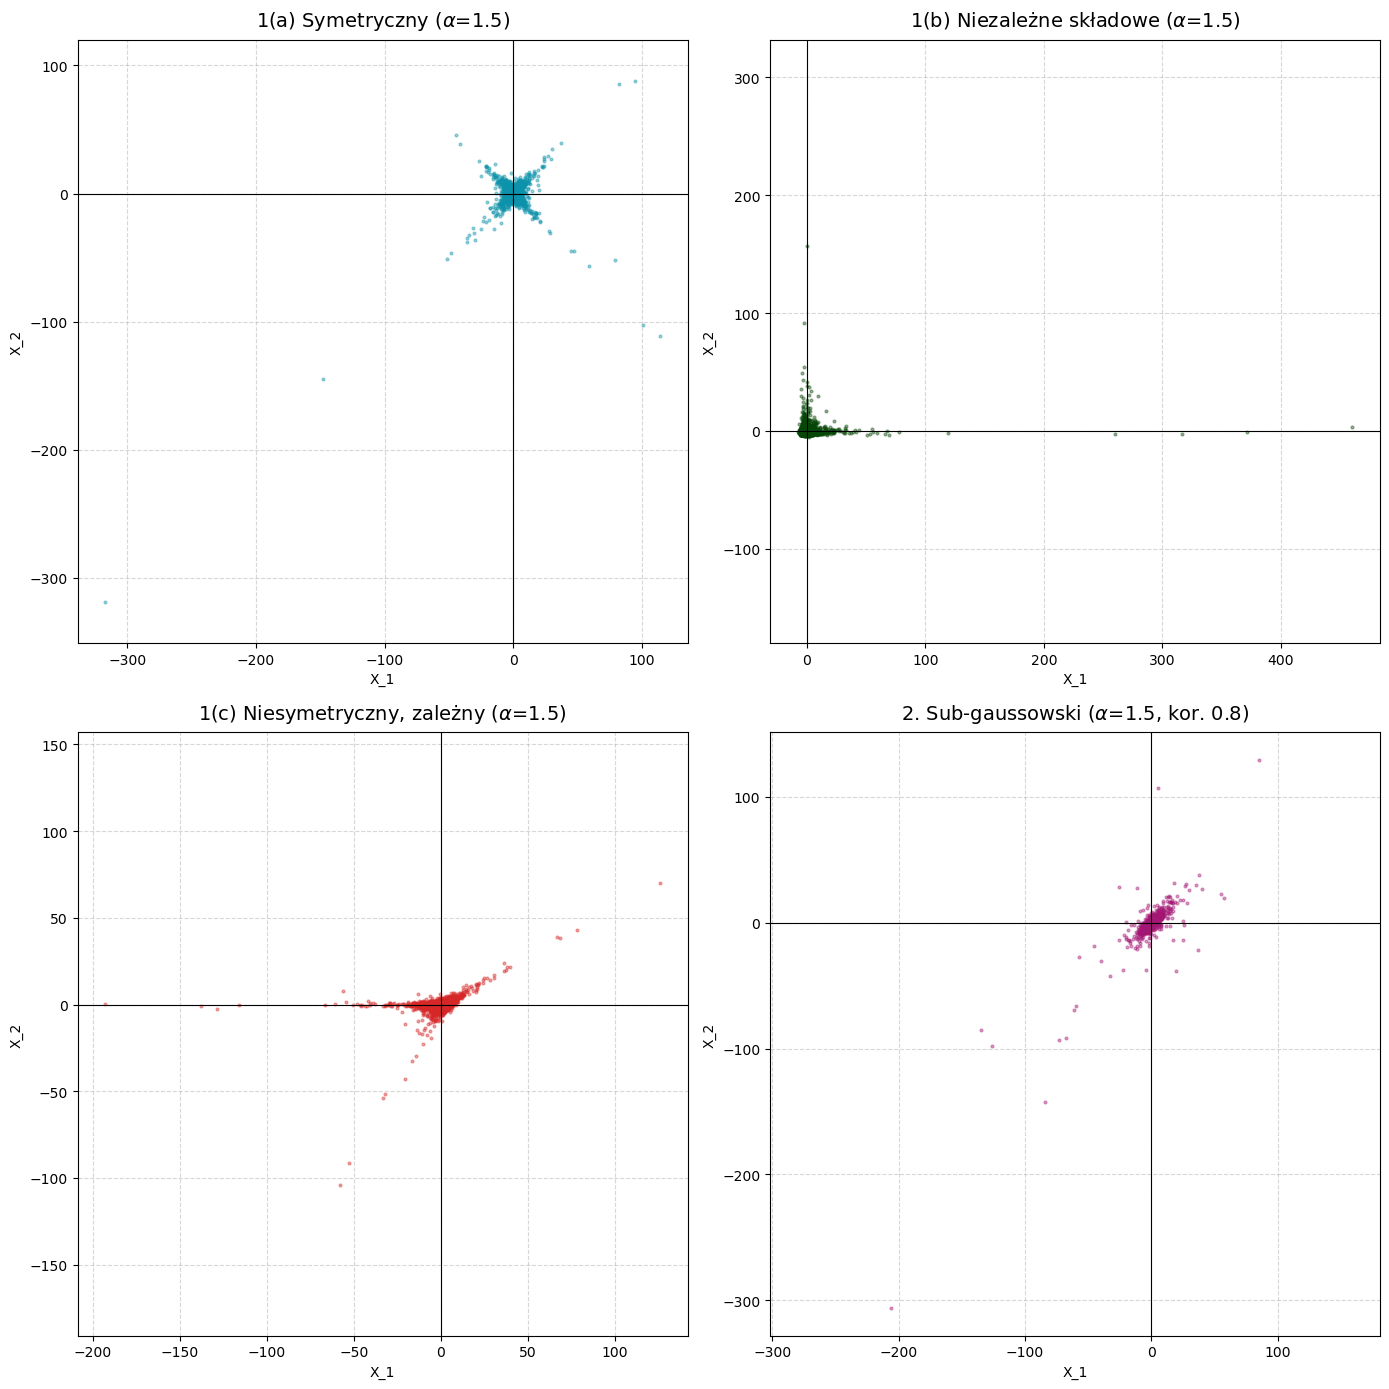

In [32]:
# ==========================================
# ZADANIE 1: Dyskretne miary spektralne
# ==========================================

# 1(a) Symetryczny (punkty co 90 stopni, ale pod kątem, np. 45, 135, 225, 315 stopni)
angles_sym = [np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4]
weights_sym = [1.0, 1.0, 1.0, 1.0]
X_sym = generate_discrete_stable_2d_user(alpha_test, angles_sym, weights_sym, n_samples_plot)

# 1(b) Niezależne składowe (masy TYLKO na osiach, tutaj osie dodatnie)
angles_ind = [0, np.pi/2]
weights_ind = [2.0, 1.0] # Wagi mogą być różne
X_ind = generate_discrete_stable_2d_user(alpha_test, angles_ind, weights_ind, n_samples_plot)

# 1(c) Niesymetryczny i zależny (masy rozłożone nieregularnie)
angles_asym = [np.pi/6, np.pi, 4*np.pi/3]
weights_asym = [1.0, 2.5, 0.5]
X_asym = generate_discrete_stable_2d_user(alpha_test, angles_asym, weights_asym, n_samples_plot)

# ==========================================
# ZADANIE 2: Wektor sub-gaussowski
# ==========================================

# Silna korelacja dodatnia (0.8), aby rozkład był wyraźnie kierunkowy
cov_matrix = [[1.0, 0.8], 
              [0.8, 1.0]]
X_subg = generate_subgaussian_2d_user(alpha_test, cov_matrix, n_samples_plot)

# ==========================================
# WIZUALIZACJA (Scatterplots)
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# Zestaw wspólnych ustawień dla wykresów
def style_axis(ax, title):
    ax.set_title(title, fontsize=14, pad=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('X_1')
    ax.set_ylabel('X_2')
    # Opcjonalnie równe skalowanie osi (przydatne do widzenia prawdziwych kątów)
    ax.axis('equal') 

# Wykres 1(a)
axes[0, 0].scatter(X_sym[:, 0], X_sym[:, 1], s=4, alpha=0.4, color="#0c92aa")
style_axis(axes[0, 0], f"1(a) Symetryczny ($\\alpha$={alpha_test})")

# Wykres 1(b)
axes[0, 1].scatter(X_ind[:, 0], X_ind[:, 1], s=4, alpha=0.4, color="#064606")
style_axis(axes[0, 1], f"1(b) Niezależne składowe ($\\alpha$={alpha_test})")

# Wykres 1(c)
axes[1, 0].scatter(X_asym[:, 0], X_asym[:, 1], s=4, alpha=0.4, color='#d62728')
style_axis(axes[1, 0], f"1(c) Niesymetryczny, zależny ($\\alpha$={alpha_test})")

# Wykres 2
axes[1, 1].scatter(X_subg[:, 0], X_subg[:, 1], s=4, alpha=0.4, color="#a31674")
style_axis(axes[1, 1], f"2. Sub-gaussowski ($\\alpha$={alpha_test}, kor. 0.8)")

plt.tight_layout()
plt.show()

### Zadanie 3:
(20%) Napisz funkcję/skrypt estymujący α oraz miarę spektralną Γ dla zadanej próbki.\
(a) Sprawdź swoje estymatory na próbkach przedstawionych w zadaniach 1 i 2.\
W przypadku estymatora Γ rozważ jedną ustaloną wartość R.

### Uwagi do zadań 3/4/5/6
#### Uwaga 1 
Dla estymacji miary spektralnej: bądź w stanie określić, czy miara jest dyskretna
czy ciągła.
#### Uwaga 2
Do prezentacji wyników używaj innych miar spektralnych niż występowały na listach
z laboratoriów. Nie rozważaj też przypadku gaussowskiego, jako że ma niejednoznaczną
miarę spektralną

In [35]:
def estimate_spectral_measure(X, R):
    """Estymacja ciągłej/dyskretnej miary spektralnej po odcięciu R."""
    norms = np.linalg.norm(X, axis=1)
    extreme_X = X[norms > R]
    angles = np.arctan2(extreme_X[:, 1], extreme_X[:, 0])
    return np.mod(angles, 2 * np.pi)

Prawdziwe alpha: 1.5
Zbiór: 1(a) Symetryczny................... Wyestymowane alpha: 1.707
Zbiór: 1(b) Niezależne składowe........... Wyestymowane alpha: 1.451
Zbiór: 1(c) Niesymetryczny, zależny....... Wyestymowane alpha: 1.673
Zbiór: 2. Sub-gaussowski.................. Wyestymowane alpha: 1.544


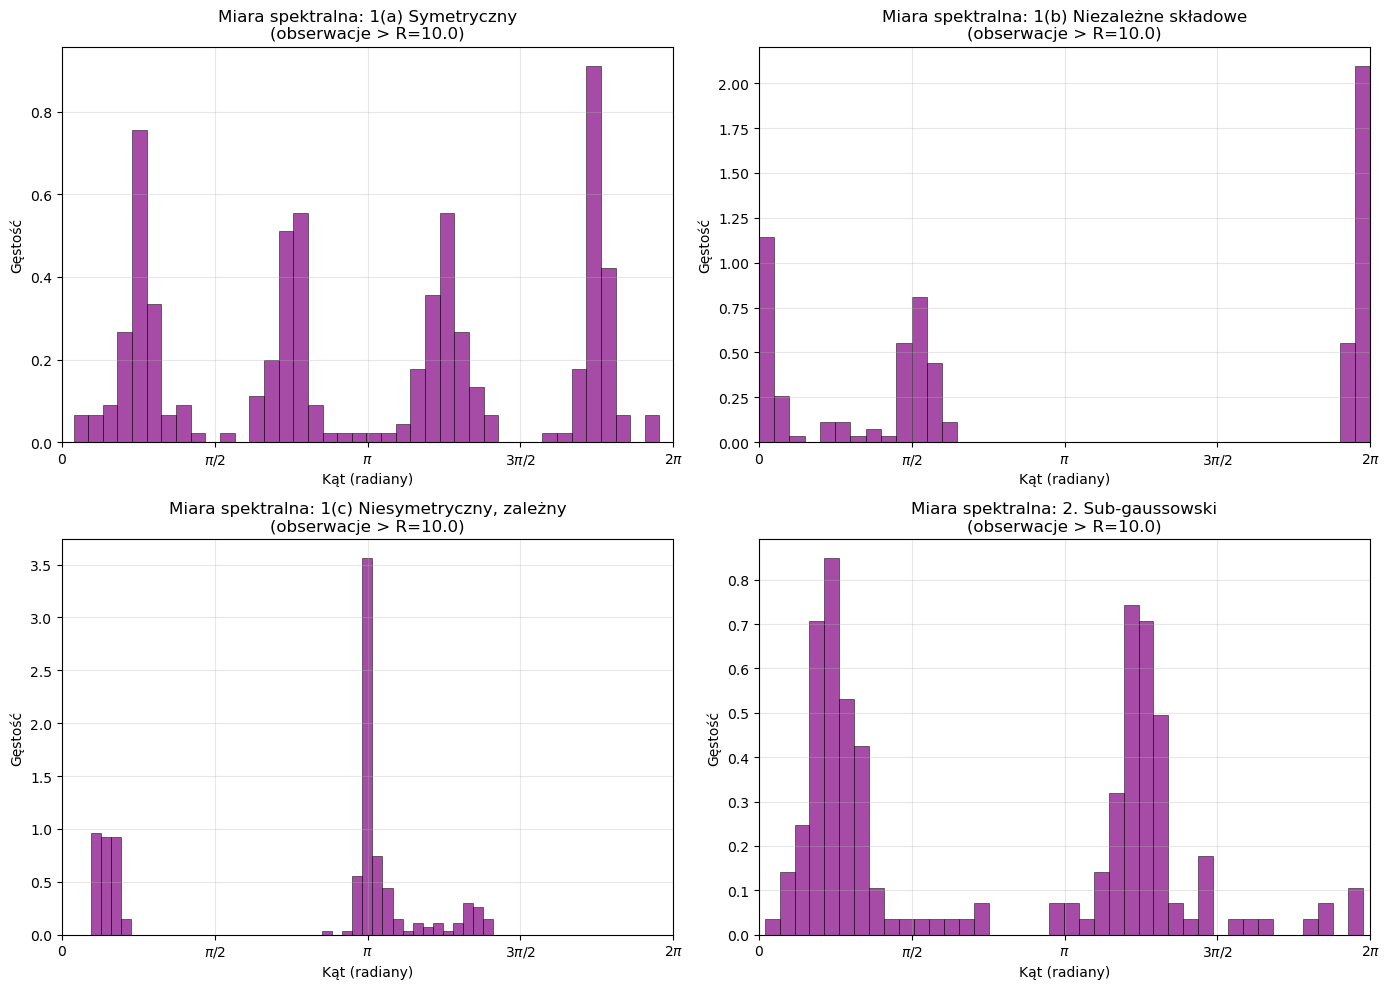

In [37]:
R_val = 10.0

# Próbki z poprzednich zadań |-> słownik
datasets = {
    "1(a) Symetryczny": X_sym,
    "1(b) Niezależne składowe": X_ind,
    "1(c) Niesymetryczny, zależny": X_asym,
    "2. Sub-gaussowski": X_subg
}

print(f"Prawdziwe alpha: {alpha_test}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, X_data) in enumerate(datasets.items()):
    # 1. Estymacja alpha na podstawie norm (długości wektorów)
    norms = np.linalg.norm(X_data, axis=1)
    est_alpha = estimate_alpha_ecdf(norms, tail_fraction=0.1)
    print(f"Zbiór: {name:.<35} Wyestymowane alpha: {est_alpha:.3f}")
    
    # 2. Estymacja miary spektralnej (histogram kątów powyżej ustalonego R)
    angles_est = estimate_spectral_measure(X_data, R_val)
    
    ax = axes[idx]
    # density=True => pole pod histogramem sumuje się do 1
    ax.hist(angles_est, bins=40, density=True, color='purple', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(f"Miara spektralna: {name}\n(obserwacje > R={R_val})")
    ax.set_xlabel("Kąt (radiany)")
    ax.set_ylabel("Gęstość")
    ax.grid(True, alpha=0.3)
    
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(['0', '$\pi/2$', '$\pi$', '$3\pi/2$', '$2\pi$'])

plt.tight_layout()
plt.show()

### Zadanie 4:
(20%) Napisz funkcję/skrypt estymujący funkcję charakterystyczną dla danych wielowymiarowych
(dwuwymiarowych).\
(a) Narysuj jej część rzeczywistą i urojoną na obszarze [−2, 2] × [−2, 2] przy użyciu
wykresu konturowego (contourplot).\
(b) Porównaj teoretyczną funkcję charakterystyczną wektora sub-gaussowskiego z zadania 2 z jej estymacją.

Empiryczna funkcja charakterystyczna (ECF) dla próbki $\mathbf{x}_1, \dots, \mathbf{x}_N$ jest zdefiniowana jako średnia:$$\hat{\phi}(\mathbf{t}) = \frac{1}{N} \sum_{k=1}^N \exp(i \langle \mathbf{t}, \mathbf{x}_k \rangle).$$
Dla teoretycznego rozkładu sub-gaussowskiego z wektorem kowariancji $\Sigma$, funkcja charakterystyczna ma postać zamkniętą:
  $$\phi_{sub}(\mathbf{t}) = \exp \left( - \left( \frac{1}{2} \mathbf{t}^T \Sigma \mathbf{t} \right)^{\alpha/2} \right).$$

Obliczam empiryczną CF...
Obliczam teoretyczną CF...


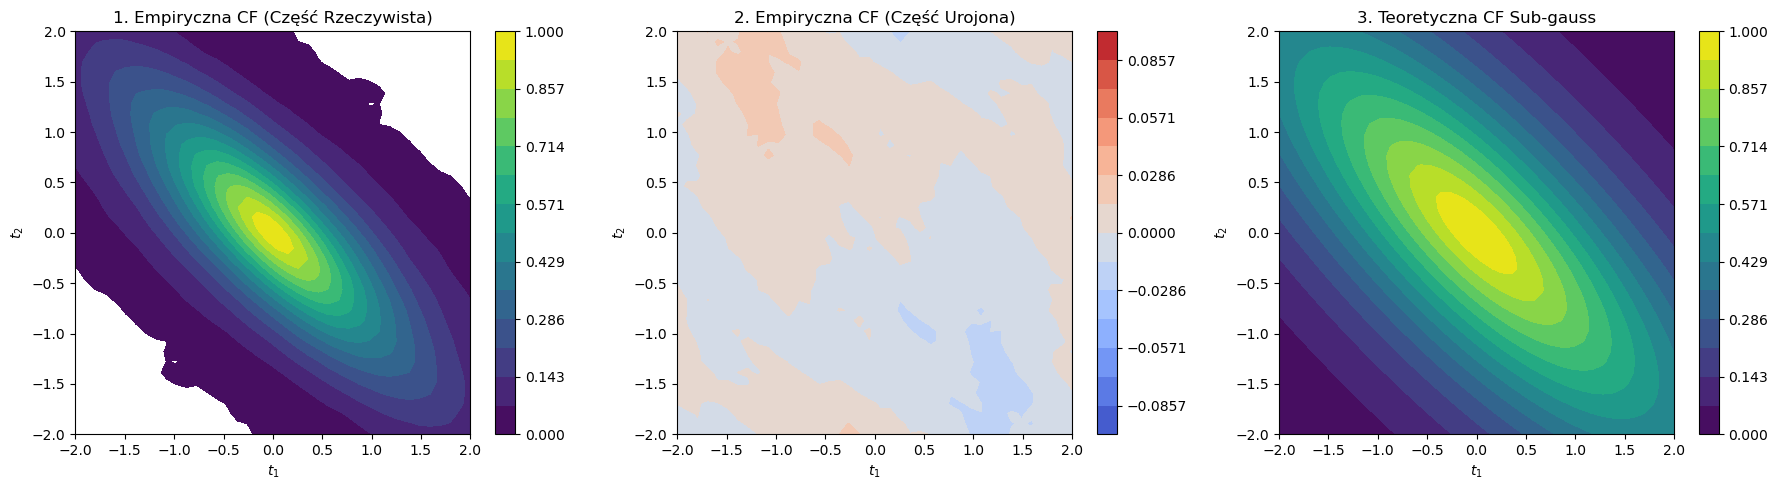

Błąd średniokwadratowy (MSE) między Estymacją a Teorią: 0.067892


In [ ]:
def empirical_cf_2d(X, T1, T2):
    """Estymacja empirycznej funkcji charakterystycznej na siatce T1, T2."""
    ECF = np.zeros_like(T1, dtype=complex)
    for i in range(T1.shape[0]):
        for j in range(T1.shape[1]):
            t = np.array([T1[i,j], T2[i,j]])
            ECF[i,j] = np.mean(np.exp(1j * np.dot(X, t)))
    return ECF

def theoretical_cf_subgaussian(T1, T2, alpha, cov_matrix):
    """Teoretyczna funkcja charakterystyczna rozkładu sub-gaussowskiego."""
    CF = np.zeros_like(T1, dtype=float)
    cov = np.array(cov_matrix)
    for i in range(T1.shape[0]):
        for j in range(T1.shape[1]):
            t = np.array([T1[i,j], T2[i,j]])
            quadratic_form = 0.5 * np.dot(t.T, np.dot(cov, t))
            CF[i,j] = np.exp(- (quadratic_form)**(alpha/2))
    return CF

# 1. Definiujemy siatkę [-2, 2] x [-2, 2]
grid_points = np.linspace(-2, 2, 40)
T1, T2 = np.meshgrid(grid_points, grid_points)

ECF_subg = empirical_cf_2d(X_subg, T1, T2)
CF_theo = theoretical_cf_subgaussian(T1, T2, alpha_test, cov_matrix)

# ==========================================
# WIZUALIZACJA: Porównanie (Contourplots)
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Wykres 1: ECF Część Rzeczywista
levels = np.linspace(0, 1, 15)
c1 = axes[0].contourf(T1, T2, np.real(ECF_subg), levels=levels, cmap='viridis')
axes[0].set_title("1. Empiryczna CF (Część Rzeczywista)")
axes[0].set_xlabel("$t_1$")
axes[0].set_ylabel("$t_2$")
fig.colorbar(c1, ax=axes[0])

# Wykres 2: ECF Część Urojona
# Uwaga: Urojona część powinna oscylować wokół 0 (z def. funkcja char. to wartość oczekiawana: E[exp(i*t^T*X)], ze wzoru Eulera:
# E[exp(i*t^T*X)] = E[cos(t^T*X)] + i*E[sin(t^T*X)]. Ponieważ X - symetryczy i sin - nieparzysty -> E[sin(t^T*X)] = 0)
levels_imag = np.linspace(-0.1, 0.1, 15) 
c2 = axes[1].contourf(T1, T2, np.imag(ECF_subg), levels=levels_imag, cmap='coolwarm')
axes[1].set_title("2. Empiryczna CF (Część Urojona)")
axes[1].set_xlabel("$t_1$")
axes[1].set_ylabel("$t_2$")
fig.colorbar(c2, ax=axes[1])

# Wykres 3: Teoretyczna CF (Zawsze rzeczywista i dodatnia)
c3 = axes[2].contourf(T1, T2, CF_theo, levels=levels, cmap='viridis')
axes[2].set_title("3. Teoretyczna CF Sub-gauss")
axes[2].set_xlabel("$t_1$")
axes[2].set_ylabel("$t_2$")
fig.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.show()

mse = np.mean((np.real(ECF_subg) - CF_theo)**2)
print(f"Błąd średniokwadratowy (MSE) między Estymacją a Teorią: {mse:.6f}")

### Zadanie 5: 
(10%+5% extra) Napisz funkcję/skrypt estymujący miarę kodiferencji dla zadanej
próbki dwuwymiarowej.\
Przedstaw wyniki dla kilku wybranych dwuwymiarowych rozkładów stabilnych (rozważ
różne α i/lub różne miary spektralne Γ).\
Dodatkowo: dla wybranego przypadku miary spektralnej oblicz teoretyczną kodiferencję
(i porównaj ją z wynikiem estymacji).

Kodiferencja $\tau$ to miara zależności dla rozkładów z grubymi ogonami (gdzie kowariancja może nie istnieć). Oblicza się ją ze wzoru:
$$\tau(X_1, X_2) = \ln \phi(1, -1) - \ln \phi(1, 0) - \ln \phi(0, -1).$$
Zauważamy, że dla części rzeczywistej:
$$\text{Re}(\tau) = \ln |\phi(1, -1)| - \ln |\phi(1, 0)| - \ln |\phi(0, -1)|.$$
Dla miary spektralnej dyskretnej z Zadania 1 (masy $\gamma_j$ na kątach $\theta_j$), moduł teoretycznej funkcji charakterystycznej wynosi:
$$\ln |\phi(t_1, t_2)| = - \sum_{j} \gamma_j |t_1 \cos\theta_j + t_2 \sin\theta_j|^\alpha.$$
Podstawiając do tego wektory $t=(1,-1)$, $t=(1,0)$ oraz $t=(0,-1)$, otrzymujemy:
$$\tau_{teor} = \sum_{j} \gamma_j \left( |\cos\theta_j|^\alpha + |-\sin\theta_j|^\alpha - |\cos\theta_j - \sin\theta_j|^\alpha \right).$$


In [ ]:
def estimate_codifference_empirical(X):
    """Estymator empirycznej kodiferencji (część rzeczywista)."""
    phi_1 = np.mean(np.exp(1j * (X[:, 0] - X[:, 1]))) 
    phi_2 = np.mean(np.exp(1j * X[:, 0]))            
    phi_3 = np.mean(np.exp(1j * (-X[:, 1])))         
    
    # Re(tau) = ln|phi(1,-1)| - ln|phi(1,0)| - ln|phi(0,-1)|
    tau = np.log(np.abs(phi_1)) - np.log(np.abs(phi_2)) - np.log(np.abs(phi_3))
    return tau

def theoretical_codifference_discrete(alpha, angles, weights):
    """Oblicza teoretyczną kodiferencję dla zadanej miary dyskretnej."""
    angles = np.array(angles)
    weights = np.array(weights)
    
    # \sum \gamma_j ( |cos|^\alpha + |-sin|^\alpha - |cos - sin|^\alpha )
    term1 = np.abs(np.cos(angles))**alpha
    term2 = np.abs(-np.sin(angles))**alpha
    term3 = np.abs(np.cos(angles) - np.sin(angles))**alpha
    
    tau_theo = np.sum(weights * (term1 + term2 - term3))
    return tau_theo

# Definiujemy warianty miar spektralnych do testów
measures = {
    "Niezależne": {"angles": [0, np.pi/2], "weights": [1.0, 1.0]},
    "Symetryczne": {"angles": [np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4], "weights": [1.0, 1.0, 1.0, 1.0]},
    "Niesymetryczne (zależne)": {"angles": [np.pi/6, np.pi, 4*np.pi/3], "weights": [2.0, 1.5, 0.5]}
}

alphas_to_test = [1.3, 1.8]
n_samples = 20000

print(f"{'Miara Spektralna':<26} | {'Alpha':<5} | {'Tau (Empiryczne)':<16} | {'Tau (Teoria)':<12}")
print("-" * 68)

for alpha in alphas_to_test:
    for name, params in measures.items():
        angles = params["angles"]
        weights = params["weights"]
        
        tau_theo = theoretical_codifference_discrete(alpha, angles, weights)
        
        X = generate_discrete_stable_2d_user(alpha, angles, weights, n_samples)
        tau_emp = estimate_codifference_empirical(X)
        
        print(f"{name:<26} | {alpha:<5} | {tau_emp:>16.5f} | {tau_theo:>12.5f}")
    print("-" * 68)

print("Fakt/Obserwacja:")
print("Dla zmiennych niezależnych kodiferencja wynosi teoretycznie 0 (i empirycznie blisko 0).")

Miara Spektralna           | Alpha | Tau (Empiryczne) | Tau (Teoria)
--------------------------------------------------------------------
Niezależne                 | 1.3   |         -0.02966 |      0.00000
Symetryczne                | 1.3   |          2.04233 |      1.95991
Niesymetryczne (zależne)   | 1.3   |          2.16498 |      2.41207
--------------------------------------------------------------------
Niezależne                 | 1.8   |          0.02935 |      0.00000
Symetryczne                | 1.8   |          0.57951 |      0.55496
Niesymetryczne (zależne)   | 1.8   |          2.33587 |      2.23815
--------------------------------------------------------------------
Fakt/Obserwacja:
Dla zmiennych niezależnych kodiferencja wynosi teoretycznie 0 (i empirycznie blisko 0).


### Zadanie 6: 
(30%, możliwe +10% za dodatkowe analizy) Rozważ problem wyznaczenia „optymalnego”
wyboru parametru R w estymatorze miary spektralnej. Zaproponuj kryterium i
poprzez symulacje sprawdź, czy taki wybór zależy od rzeczywistej miary spektralnej Γ
oraz α. (Rozważ tylko jedną długość próby.)\
Dodatkowo możesz przedstawić wykres odwzorowania α → R∗ (R∗ oznacza optymalne
R).

Symulacja dla alpha = 1.2...


Symulacja dla alpha = 1.4...


Symulacja dla alpha = 1.6...


Symulacja dla alpha = 1.8...


Symulacja dla alpha = 1.9...


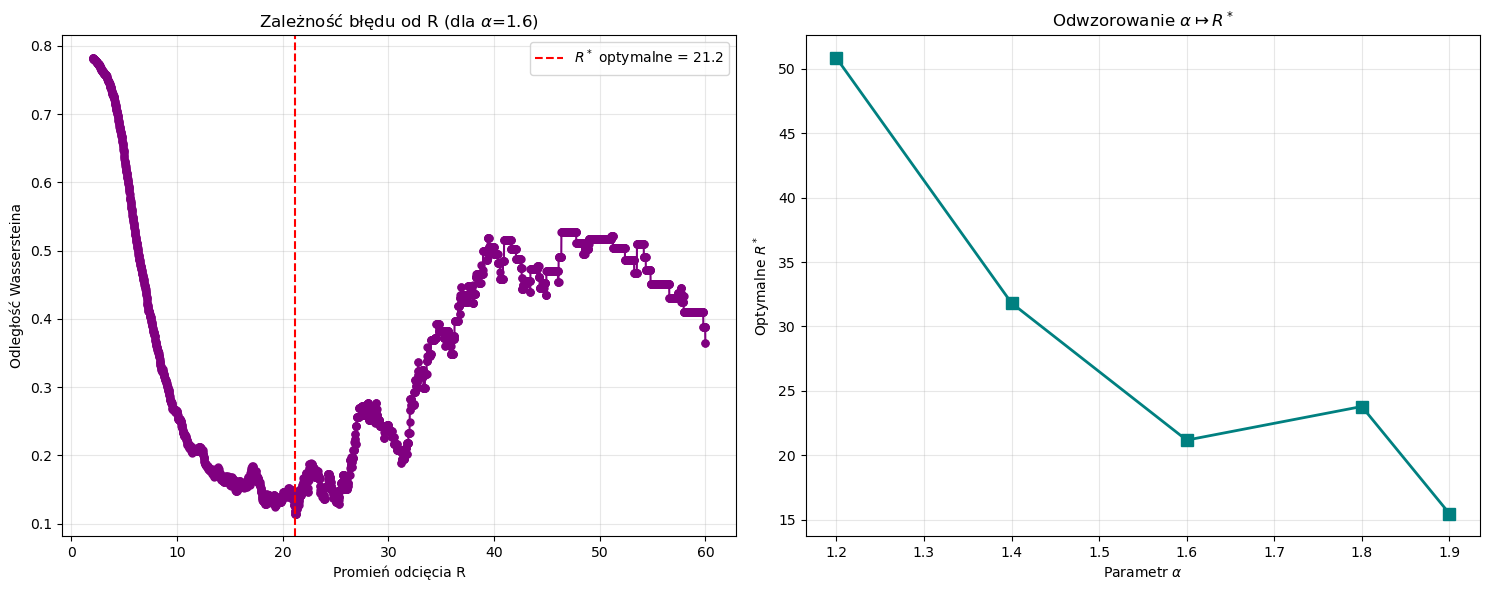

In [51]:
def find_optimal_R_user(alphas, angles_true, weights_true, n_samples=20000, R_grid=np.linspace(1, 50, 40)):
    """
    Znajduje optymalne R dla różnych alpha.
    Kryterium: Minimalizacja odległości Wassersteina między estymowaną a prawdziwą miarą spektralną.
    """
    # Normalizacja wag (wagi teoretyczne muszą sumować się do 1, by być miarą prawdopodobieństwa)
    weights_normalized = np.array(weights_true) / np.sum(weights_true)
    
    optimal_Rs = []
    distances_per_alpha = {}

    for alpha in alphas:
        print(f"Symulacja dla alpha = {alpha}...")
        
        X = generate_discrete_stable_2d_user(alpha, angles_true, weights_true, n_samples)
        
        distances = []
        valid_R_grid = []
        
        # Przeszukujemy grid możliwych promieni R
        for R in tqdm(R_grid, leave=False):
            # Używamy funkcji estymującej z zadania 3
            angles_est = estimate_spectral_measure(X, R)
            
            # Zabezpieczenie: jeśli R jest tak duże, że odcina nam prawie całą próbę
            if len(angles_est) < 5:
                continue
            
            # Obliczamy odległość Wassersteina
            # u_values = wyestymowane kąty (domyślnie każda próbka ma wagę 1/N)
            # v_values = prawdziwe kąty (mają wagi równe prawdziwej mierze)
            dist = wasserstein_distance(angles_est, angles_true, v_weights=weights_normalized)
            
            distances.append(dist)
            valid_R_grid.append(R)
            
        distances_per_alpha[alpha] = (valid_R_grid, distances)
        
        # Znajdujemy R*, dla którego błąd był najmniejszy
        if distances:
            min_idx = np.argmin(distances)
            optimal_Rs.append(valid_R_grid[min_idx])
        else:
            optimal_Rs.append(np.nan)
            
    return optimal_Rs, distances_per_alpha


n_samples = 20000 
alphas_to_test = [1.2, 1.4, 1.6, 1.8, 1.9]

# 3 punkty nierozłożone równomiernie
angles_test = [np.pi/6, np.pi, 5*np.pi/3] 
weights_test = [2.0, 1.5, 3.0]

# Proponowany grid dla sprawdzanych wartości R
R_values_to_test = np.linspace(2, 60, 4000)

R_stars, distances_dict = find_optimal_R_user(
    alphas_to_test, angles_test, weights_test, 
    n_samples=n_samples, R_grid=R_values_to_test
)

# ==========================================
# WIZUALIZACJA
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# WYKRES 1: Błąd estymacji względem R dla przykładowego alpha
example_alpha = 1.6
r_grid, dists = distances_dict[example_alpha]
axes[0].plot(r_grid, dists, marker='o', markersize=5, linestyle='-', color='purple')
axes[0].set_title(f"Zależność błędu od R (dla $\\alpha$={example_alpha})")
axes[0].set_xlabel("Promień odcięcia R")
axes[0].set_ylabel("Odległość Wassersteina")

# Zaznaczamy znalezione minimum w pionie
idx = alphas_to_test.index(example_alpha)
axes[0].axvline(R_stars[idx], color='red', linestyle='--', label=f"$R^*$ optymalne = {R_stars[idx]:.1f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# WYKRES 2: Odwzorowanie alpha -> R*
axes[1].plot(alphas_to_test, R_stars, marker='s', markersize=8, color='teal', linestyle='-', linewidth=2)
axes[1].set_title("Odwzorowanie $\\alpha \\mapsto R^*$")
axes[1].set_xlabel("Parametr $\\alpha$")
axes[1].set_ylabel("Optymalne $R^*$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()